In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [5]:
len(words)

32033

In [7]:
# building the vocabulary of the characters and mapping to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(f'{vocab_size=}')

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
vocab_size=27


In [10]:
# build the data set
block_size = 3 # How many characters do we want to predict the next one?

def build_dataset(word):
  X, Y = [], []

  for w in word:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix]

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(f'{X.shape=}, {Y.shape=}')
  return X, Y


import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])      # 80%
Xdev, Ydev = build_dataset(words[n1:n2])  # 10%
Xte, Yte = build_dataset(words[n2:])      # 10%

X.shape=torch.Size([182437, 3]), Y.shape=torch.Size([182437])
X.shape=torch.Size([22781, 3]), Y.shape=torch.Size([22781])
X.shape=torch.Size([22928, 3]), Y.shape=torch.Size([22928])


In [12]:
# MLP revisited

n_embd = 10 # the dimensionality of the character embedding vector
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((vocab_size, n_embd),             generator=g)
W1 = torch.randn((block_size * n_embd, n_hidden), generator=g)
b1 = torch.randn(n_hidden,                        generator=g)
W2 = torch.randn((n_hidden, vocab_size),          generator=g)
b2 = torch.randn(vocab_size,                      generator=g)

parameters = [C, W1, b1, W2, b2]
print(f'Total Num of Parameters: {sum(p.nelement() for p in parameters)}') # number of parameters in total
for p in parameters:
  p.requires_grad=True

Total Num of Parameters: 11897


In [13]:
# training on Xtr data
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size, ), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix]

  # forward pass
  emb = C[Xb] # embedded characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate vectors
  hpreact = embcat @ W1 + b1 # hidden layer pre-activation
  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function


  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # calculating learning rate with decay
  x = i / max_steps
  lr = 0.1 - 0.099 * torch.exp(torch.tensor(10 * (x - 1))) # learning decay

  # update
  for p in parameters:
    p.data += -lr * p.grad

  # track status
  if i % 10000 == 0: # print per every 10000 iterations
    print(f'{i:7d}/{max_steps:7d}: {loss.item():4f}')
  lossi.append(loss.log10().item())


      0/ 200000: 25.526192
  10000/ 200000: 1.917815
  20000/ 200000: 2.261144
  30000/ 200000: 2.364841
  40000/ 200000: 2.584969
  50000/ 200000: 1.907843
  60000/ 200000: 2.682603
  70000/ 200000: 2.413120
  80000/ 200000: 1.968904
  90000/ 200000: 2.481373
 100000/ 200000: 2.269427
 110000/ 200000: 2.146499
 120000/ 200000: 2.149339
 130000/ 200000: 1.780030
 140000/ 200000: 2.609984
 150000/ 200000: 2.287723
 160000/ 200000: 2.014901
 170000/ 200000: 2.384321
 180000/ 200000: 2.758769
 190000/ 200000: 1.788853


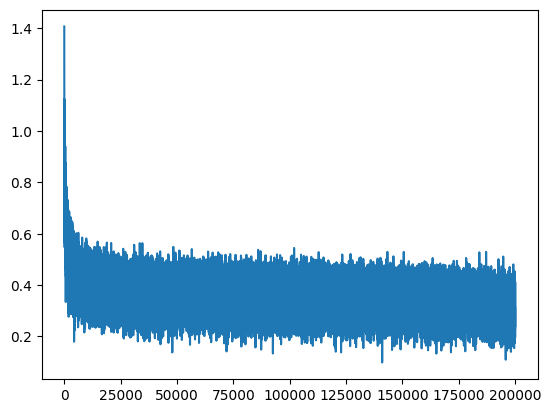

In [14]:
plt.plot(lossi)

In [15]:
@torch.no_grad() # this decorator disables gradient tracking for the following function
def split_loss(split):
  x, y = {
     'train': (Xtr, Ytr),
     'val': (Xdev, Ydev),
     'test': (Xte, Yte)
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  h = torch.tanh(embcat @ W1 + b1) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())


split_loss('train')
split_loss('val')



train 2.080470561981201
val 2.1485979557037354


In [17]:
# sample from the model

g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

  out = []
  context = [0] * block_size # initialize with all ...

  while True:
    # forward pass the neural net
    emb = C[torch.tensor(context)] # (1, block_size, n_embd)
    h = torch.tanh(emb.view(1, -1) @ W1 + b1)
    logits = h @ W2 + b2
    prob = F.softmax(logits,dim=1)
    # sample from distribution
    ix = torch.multinomial(prob, num_samples=1, generator=g).item()
    context = context[1:] + [ix]
    out.append(itos[ix])
    # if we sample the special '.' token, break
    if ix == 0:
      break

  print(''.join(c for c in out)) # decode and print the generated word


carmahza.
jahmarik.
mili.
tatyah.
cassie.
mahito.
delynn.
jareei.
ner.
kia.
chaiivia.
legyn.
ham.
joce.
quintin.
lilah.
jadii.
watell.
dearynix.
kael.
